In [2]:
import matplotlib.pyplot as plt
from glob import glob
import matplotlib.patches as mpatches
# import cosima_cookbook as cc
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
import cmocean.cm as cm
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cft
import gc
from scipy.interpolate import griddata
from matplotlib import ticker
import scipy.io as sio
import seaborn as sns
import matplotlib.patheffects as pe
from scipy import stats
import matplotlib.patheffects as mpe
from tqdm import tqdm

In [3]:
def argnear(dat,val,how_many=1):
    dif = np.abs(dat-val)
    idx = np.argsort(dif)
    return idx[:how_many]

In [4]:
# Set figures properties
# sns.set_style('whitegrid')
# sns.reset_orig()
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

## Import cloud cover

In [2]:
# path = '/g/data/rt52/era5/single-levels/monthly-averaged/2t/'
# path = '/g/data/rt52/era5/single-levels/monthly-averaged-by-hour/2t/'
path = '/g/data/rt52/era5/single-levels/reanalysis/tcc/'
year = np.arange(1993,2020,1) 
files = np.array([])
## The files are in different directories
for i in range(len(year)):
    file = glob(path + str(year[i]) + '/*')
    file.sort()
    files = np.append(files, file)

In [11]:
from functools import partial
def _preprocess(ds, lon_bnds, lat_bnds):
    return ds.sel(longitude = lon_bnds, latitude = lat_bnds)

yt_sel = slice(-37, -45)
xt_sel = slice(20, 65)
partial_func = partial(_preprocess, lon_bnds=xt_sel, lat_bnds=yt_sel)
data = xr.open_mfdataset(list(files), preprocess=partial_func)  

In [12]:
time_sel = slice('1993-01-01', '2019-05-31')
cloud    = data.tcc.sel(time=time_sel)
cloud_daily = cloud.resample(time='1D').mean('time').compute()*100 ## I mulitply to a hundred to obtain in percentage


In [14]:
cloud_mean_region = cloud_daily.mean(dim=['latitude','longitude'])
time_xaxis = np.arange(len(cloud_daily.time))

theil_sen_cloud = stats.theilslopes(cloud_mean_region, time_xaxis, 0.90)
least_sqr_cloud = stats.linregress(time_xaxis, cloud_mean_region)

#### I'll include the values below in Amelie's table

In [17]:
theil_sen_cloud.slope*(365*10 + 2)

np.float64(0.4882193362131971)

In [18]:
least_sqr_cloud.slope*(365*10 + 2)

np.float64(0.5177593139222295)

In [20]:
least_sqr_cloud.pvalue

np.float64(1.0914578739591978e-05)

## Import SST time series

In [4]:
# path = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/data/'
path = '/g/data/jk72/fs3401/Desktop/AmelieMeyer_Agulhas_meander/data/'
time_sel = slice('1993-01-01', '2019-05-31')
SST  = xr.open_dataset(path+'sst_19820101-20211231_fromChrisC.nc').sst.load()[:,0]
SST = SST.sel().sel(time=time_sel)
lon_SST, lat_SST = SST.lon, SST.lat

In [8]:
yt_sel  = slice(-45, -37); xt_sel = slice(20, 65)
SST_sel = SST.sel(lat = yt_sel, lon = xt_sel)

## Near-surface atmospheric temperature using the 1/4$^\circ$ ERA5

In [7]:
path = '/g/data/rt52/era5/single-levels/reanalysis/2t/'
year = np.arange(1993,2020,1) # The daily data in 2000 is between the output folders from 108 and 119
files = np.array([])
## The files are in different directories
for i in range(len(year)):
    file = glob(path + str(year[i]) + '/*')
    file.sort()
    files = np.append(files, file)

In [9]:
from functools import partial
def _preprocess(ds, lon_bnds, lat_bnds):
    return ds.sel(longitude = lon_bnds, latitude = lat_bnds)

yt_sel  = slice(-37, -45); xt_sel = slice(20, 65)
partial_func = partial(_preprocess, lon_bnds=xt_sel, lat_bnds=yt_sel)
data = xr.open_mfdataset(list(files), preprocess=partial_func)  

In [17]:
Ta       = data.t2m.sel(time=time_sel) - 273.15
Ta_daily = Ta.resample(time='1D').mean('time').compute()

## Near-surface atmospheric wind using the 1/4$^\circ$ ERA5

In [10]:
path_u = '/g/data/rt52/era5/single-levels/reanalysis/10u/'
path_v = '/g/data/rt52/era5/single-levels/reanalysis/10v/'
year = np.arange(1993,2020,1) # The daily data in 2000 is between the output folders from 108 and 119
files_u, files_v = np.array([]), np.array([])
## The files are in different directories
for i in range(len(year)):
    file_u, file_v = glob(path_u + str(year[i]) + '/*'), glob(path_v + str(year[i]) + '/*')
    file_u.sort()
    file_v.sort()
    files_u = np.append(files_u, file_u)
    files_v = np.append(files_v, file_v)

In [11]:
data_u = xr.open_mfdataset(list(files_u), preprocess=partial_func)  
data_v = xr.open_mfdataset(list(files_v), preprocess=partial_func) 

In [13]:
time_sel = slice('1993-01-01', '2019-05-31')

u_atm   = data_u.u10.sel(time=time_sel)
u_atm_daily = u_atm.resample(time='1D').mean('time').compute()
##############################################################
v_atm   = data_v.v10.sel(time=time_sel)
v_atm_daily = v_atm.resample(time='1D').mean('time').compute()
##############################################################
wind_speed = np.array([np.sqrt(u_atm_daily[t]**2 + v_atm_daily[t]**2) for t in tqdm(range(len(u_atm_daily)))])

100%|██████████| 9647/9647 [01:35<00:00, 100.87it/s]


#### Wind stress curl

In [15]:
import gsw
lon_ERA5, lat_ERA5 = u_atm.longitude, u_atm.latitude
LON_ERA5, LAT_ERA5 = np.meshgrid(lon_ERA5, lat_ERA5)

f      = gsw.f(lat_ERA5)
ro_0   = 1025
Dc     = 15*1e-4  #Benoit
ro_air = 1.2928
tau_x  = Dc*ro_air*np.sqrt(u_atm_daily**2 + v_atm_daily**2)*u_atm_daily
tau_y  = Dc*ro_air*np.sqrt(u_atm_daily**2 + v_atm_daily**2)*v_atm_daily
##############################################################
[trash,dlonx] = np.gradient(LON_ERA5)
dx            = dlonx*np.cos(LAT_ERA5*np.pi/180)*111195.
[dlaty,trash] = np.gradient(LAT_ERA5)
dy            = dlaty*111195.
##############################################################
tau_x_dy = np.gradient(tau_x, axis = 1)
tau_y_dx = np.gradient(tau_y, axis = 2)

In [16]:
curl_wind = np.array([tau_y_dx[t]/dx - tau_x_dy[t]/dy for t in range(len(tau_x_dy))])
curl_wind_mean_region = np.nanmean(curl_wind, axis = (1,2))

In [24]:
time_xaxis = np.arange(len(curl_wind_mean_region))
# theil_sen_wstress = stats.theilslopes(curl_wind_mean_region, time_xaxis, 0.90)
# least_sqr_wstress = stats.linregress(time_xaxis, curl_wind_mean_region)
print('Slope Theil = ' + str(theil_sen_wstress.slope*(365*10 + 2)*1e7))
print('Slope LinReg  = '+ str(least_sqr_wstress.slope*(365*10 + 2)*1e7))
print('P-value  = '+ str(least_sqr_wstress.pvalue))

Slope Theil = -0.026984405933216528
Slope LinReg  = -0.034769046840878545
P-value  = 0.029863310102938447


## Near-surface atmospheric precipitation, evaporation using the 1/4$^\circ$ ERA5

In [24]:
path_mtpr = '/g/data/rt52/era5/single-levels/reanalysis/mtpr/'
path_mer  = '/g/data/rt52/era5/single-levels/reanalysis/mer/'
files_mtpr, files_mer = np.array([]), np.array([])
## The files are in different directories
for i in range(len(year)):
    file_mtpr, file_mer = glob(path_mtpr + str(year[i]) + '/*'), glob(path_mer + str(year[i]) + '/*')
    ## MTPR
    file_mtpr.sort()
    files_mtpr = np.append(files_mtpr, file_mtpr)
    ## MER
    file_mer.sort()
    files_mer  = np.append(files_mer, file_mer)

In [25]:
data_mtpr  = xr.open_mfdataset(list(files_mtpr), preprocess=partial_func) 
mtpr       = data_mtpr.mtpr.sel(time=time_sel) ## mean total precipitation rate
mtpr_daily = mtpr.resample(time='1D').mean('time').compute()*86400 # This multiplication converts the s-1 to day-1

In [26]:
data_mer  = xr.open_mfdataset(list(files_mer), preprocess=partial_func) 
mer       = data_mer.mer.sel(time=time_sel) ## mean total evaporation rate
mer_daily = mer.resample(time='1D').mean('time').compute()*86400 # This multiplication converts the s-1 to day-1

## Sensible and latent heat flux in ERA5

In [27]:
path_sshf = '/g/data/rt52/era5/single-levels/reanalysis/sshf/'
path_slhf = '/g/data/rt52/era5/single-levels/reanalysis/slhf/'
year = np.arange(1993,2020,1) 
files_sshf, files_slhf = np.array([]), np.array([])
## The files are in different directories
for i in range(len(year)):
    file_sshf, file_slhf = glob(path_sshf + str(year[i]) + '/*'), glob(path_slhf + str(year[i]) + '/*')
    file_sshf.sort()
    file_slhf.sort()
    files_sshf = np.append(files_sshf, file_sshf)
    files_slhf = np.append(files_slhf, file_slhf)

In [28]:
data_sshf = xr.open_mfdataset(list(files_sshf), preprocess=partial_func)  
data_slhf = xr.open_mfdataset(list(files_slhf), preprocess=partial_func)  

#### The division to 3600 is needed to obtain the values in W m-2
https://confluence.ecmwf.int/pages/viewpage.action?pageId=197702790

In [29]:
##############################################################
sshf   = data_sshf.sshf.sel(time=time_sel) ## surface sensible heat flux
sshf_daily = sshf.resample(time='1D').mean('time').compute()/3600 
##############################################################
slhf   = data_slhf.slhf.sel(time=time_sel) ## surface latent heat flux
slhf_daily = slhf.resample(time='1D').mean('time').compute()/3600
##############################################################

## Building the time series with the regional means

In [36]:
SST_mean_region   = SST_sel.mean(dim=['lat','lon'])
Ta_mean_region    = Ta_daily.mean(dim=['latitude','longitude'])
wd_sp_mean_region = np.nanmean(wind_speed, axis = (1,2))
mtpr_mean_region  = mtpr_daily.mean(dim=['latitude','longitude'])
mer_mean_region   = mer_daily.mean(dim=['latitude','longitude'])
sshf_mean_region  = sshf_daily.mean(dim=['latitude','longitude'])
slhf_mean_region  = slhf_daily.mean(dim=['latitude','longitude'])

## Estimating the trends

In [37]:
time_xaxis = np.arange(len(SST.time))

In [38]:
## SST
theil_sen_SST = stats.theilslopes(SST_mean_region, time_xaxis, 0.90)
least_sqr_SST = stats.linregress(time_xaxis, SST_mean_region)
## Ta
theil_sen_Ta = stats.theilslopes(Ta_mean_region, time_xaxis, 0.90)
least_sqr_Ta = stats.linregress(time_xaxis, Ta_mean_region)
## Wind speed
theil_sen_wspeed = stats.theilslopes(wd_sp_mean_region, time_xaxis, 0.90)
least_sqr_wspeed = stats.linregress(time_xaxis, wd_sp_mean_region)
## Precipitation
theil_sen_mtpr = stats.theilslopes(mtpr_mean_region, time_xaxis, 0.90)
least_sqr_mtpr = stats.linregress(time_xaxis, mtpr_mean_region)
## Evaporation
theil_sen_mer = stats.theilslopes(mer_mean_region, time_xaxis, 0.90)
least_sqr_mer = stats.linregress(time_xaxis, mer_mean_region)
## Sensible heat flux
theil_sen_sshf = stats.theilslopes(sshf_mean_region, time_xaxis, 0.90)
least_sqr_sshf = stats.linregress(time_xaxis, sshf_mean_region)
## Latent heat flux
theil_sen_slhf = stats.theilslopes(slhf_mean_region, time_xaxis, 0.90)
least_sqr_slhf = stats.linregress(time_xaxis, slhf_mean_region)

In [40]:
## p-values from the linear regression
SST_pvalue_sqr    = least_sqr_SST.pvalue
Ta_pvalue_sqr     = least_sqr_Ta.pvalue
wspeed_pvalue_sqr = least_sqr_wspeed.pvalue
mtpr_pvalue_sqr   = least_sqr_mtpr.pvalue
mer_pvalue_sqr    = least_sqr_mer.pvalue
sshf_pvalue_sqr   = least_sqr_sshf.pvalue
slhf_pvalue_sqr   = least_sqr_slhf.pvalue

In [39]:
## We need to convert from per day to per decade
SST_trend_sqr    = least_sqr_SST.slope*(365*10 + 2)
Ta_trend_sqr     = least_sqr_Ta.slope*(365*10 + 2)
wspeed_trend_sqr = least_sqr_wspeed.slope*(365*10 + 2)
mtpr_trend_sqr   = least_sqr_mtpr.slope*(365*10 + 2)
mer_trend_sqr    = least_sqr_mer.slope*(365*10 + 2)
sshf_trend_sqr   = least_sqr_sshf.slope*(365*10 + 2)
slhf_trend_sqr   = least_sqr_slhf.slope*(365*10 + 2)

In [42]:
## First, we convert from per day to per decade
SST_trend_sen    = theil_sen_SST.slope*(365*10 + 2)
Ta_trend_sen     = theil_sen_Ta.slope*(365*10 + 2)
wspeed_trend_sen = theil_sen_wspeed.slope*(365*10 + 2)
mtpr_trend_sen   = theil_sen_mtpr.slope*(365*10 + 2)
mer_trend_sen    = theil_sen_mer.slope*(365*10 + 2)
sshf_trend_sen   = theil_sen_sshf.slope*(365*10 + 2)
slhf_trend_sen   = theil_sen_slhf.slope*(365*10 + 2)

## Let's build the tables

In [44]:
cell_ = np.array([[SST_trend_sen, SST_trend_sqr, SST_pvalue_sqr],
                  [Ta_trend_sen, Ta_trend_sqr, Ta_pvalue_sqr],
                  [wspeed_trend_sen, wspeed_trend_sqr, wspeed_pvalue_sqr],
                  [mtpr_trend_sen, mtpr_trend_sqr, mtpr_pvalue_sqr],
                  [mer_trend_sen, mer_trend_sqr, mer_pvalue_sqr],
                  [sshf_trend_sen, sshf_trend_sqr, sshf_pvalue_sqr],
                  [slhf_trend_sen, slhf_trend_sqr, slhf_pvalue_sqr]])

In [49]:
columns = ['Theil-Sen trend', 'Least square trend', 'Least square p-value']
rows = ['SST', 'Ta', 'Wind speed', 'Precipitation', 'Evaporation','Sensible heat flux', 'Latent heat flux']
rcolors = plt.cm.BuPu(np.full(len(rows), 0.1))
ccolors = plt.cm.BuPu(np.full(len(columns), 0.1))
# path_fig = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/scripts/figures/'

Text(0.5, 1.0, 'Decadal trends for the regional mean between \n 20$\\degree$E--65$\\degree$E and -45$\\degree$S--37$\\degree$S ')

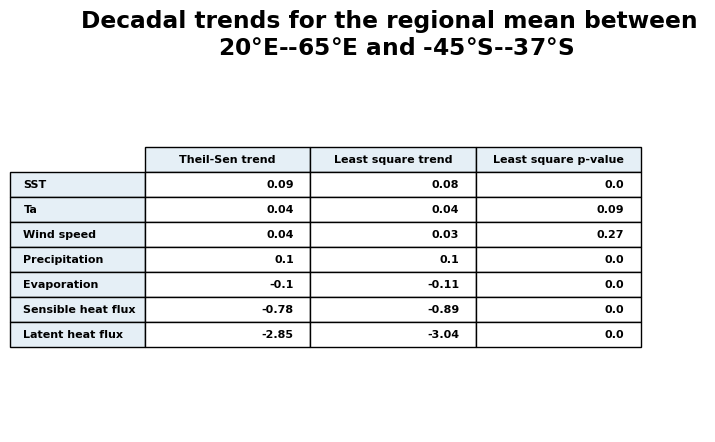

In [54]:
ax = plt.gca()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.box(on=None)

the_table = plt.table(cellText=np.round(cell_,2), 
                      rowLabels=rows,
                      loc = 'center', colLabels=columns,
                      rowColours=rcolors, rowLoc='left', colColours=ccolors,         
         )
the_table.scale(1, 1.5)


plt.title('Decadal trends for the regional mean between \n 20$\degree$E--65$\degree$E and -45$\degree$S--37$\degree$S ')
# plt.savefig(path_fig + 'Tab1_trends.jpg', dpi =300, bbox_inches = 'tight')

## Initial statistics for SST

In [36]:
time_SST = np.arange(len(SST.time))

In [27]:
theil_sen = stats.theilslopes(SST_mean_region, time_SST, 0.90)
least_sqr = stats.linregress(time_SST, SST_mean_region)

In [69]:
least_sqr.intercept  - theil_sen.intercept 

0.2587722703294002

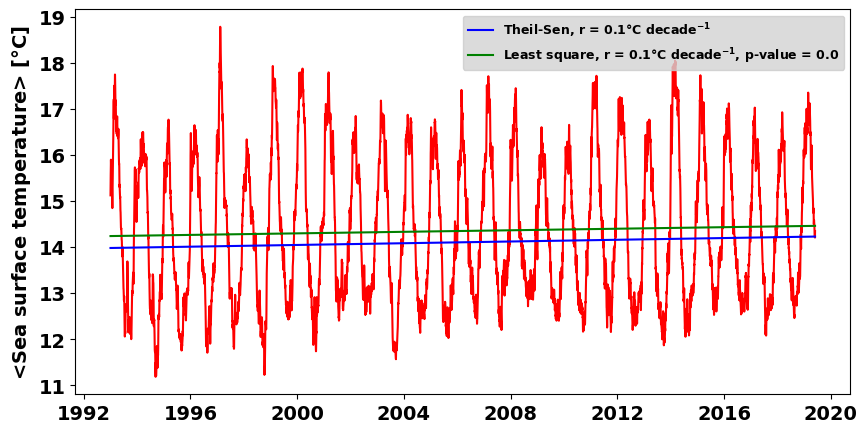

In [67]:
plt.figure(figsize=(10,5))

SST_mean_region.plot(color = 'r')
plt.plot(SST.time, theil_sen.intercept + theil_sen.slope * time_SST, 'b-', label = 'Theil-Sen, r = ' + 
         str(round(theil_sen.slope*(365*10 + 2), 1)) + '$\degree$C decade$^{-1}$')
plt.plot(SST.time, least_sqr.intercept + least_sqr.slope * time_SST, 'g-', label = 'Least square, r = ' + 
         str(round(least_sqr.slope*(365*10 + 2), 1)) + '$\degree$C decade$^{-1}$, p-value = ' + str(round(least_sqr.pvalue,1)))

## Details
plt.ylabel('<Sea surface temperature> [$\degree$C]')
plt.xlabel(''); plt.title('')
plt.legend(fontsize = 9, facecolor = 'lightgrey', loc = 'upper right')